# **Electron exibing Brownian Motion**

In this code we simulate ...

**Credits**
* Juan Andrés Guarín Rojas ([GitHub](https://github.com/AndresGuarin))


This notebook follows the next order
* [1. Computational scheme](#sec_1)

# **Import libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ECond.simulation.solver as solver
import ECond.simulation.animation as ani

from datetime import datetime
from matplotlib import cm
from matplotlib.colors import Normalize

## **Some ideas**

* Only calculate forces for the moving particles (electrons)

## **1. Computational scheme** <a class="anchor" id="sec_1"></a>

We'll use the Langevin equation to model the Brownian motion
$$m \frac{d\vec{v}_i}{dt} = -m\gamma \vec{v}_i+\vec{R}+\vec{K}_i$$

The field force is given by the Coulombs' forces between the electrons, the lorentz force due to an external electromagnetic field, and the confinement potential
$$ \vec{K}_i = q_i\left(\vec{E} + \vec{v}_i\times\vec{B} \right) - q_i \vec{\nabla} \phi +  \sum\limits_{j=1}^{N}\frac{1}{4\pi\epsilon_0}\frac{q_i q_j}{r_{ij}^3}\vec{r}_{ij}\,,$$

For implementing this equations into the code we define the next dimensionless quantities:
$$\bar{t}=\sqrt{\frac{e^2}{4\pi\epsilon_0 m_e\sigma^3}}t\,, \,\,\,\,\,\,  \vec{r}' = \frac{\vec{r}}{\sigma}\,, \,\,\,\,\,\ \vec{v}' = \frac{d\vec{r}'}{d\bar{t}}\,, \,\,\,\,\,\ \bar{r}_{ij} =\frac{r_{ij}}{\sigma}\,, \,\,\,\,\,\ \bar{q}_i = \frac{q_i}{e}$$
where $\sigma=361.5\times 10^{-12}[\text{m}]$ is the lattice constant cristal structure of copper, $e$ is the elemental charge and $m_e$ is the electron rest mass. We also define the next dimensionless fields

$$\vec{E}' = \frac{4\pi\epsilon_0 \sigma^2}{e}\vec{E}\,, \,\,\,\,\,\, \vec{B}' = \sqrt{\frac{4\pi\epsilon_0\sigma^3}{m_e}} \vec{B}\,, \,\,\,\,\,\, \phi' = \frac{4\pi\epsilon_0 \sigma^3}{e} \phi$$

With this definitions the Newton's Law of motion for the electrons is left as

$$ \frac{d\vec{v}'_{i}}{d \bar{t}}= -\bar{\gamma}\vec{v}'_i + \vec{R}'+ \bar{q}_i \left(\vec{E}'+\vec{v}'_i\times\vec{B}' \right) -\bar{q}_i\frac{\partial \phi'}{\partial \vec{r}'}+\sum\limits_{j=1}^{N} \frac{\bar{q}_i \bar{q}_j}{\bar{r}_{ij}^2}\hat{r}'_{ij} \,. $$

## **2. Test**

In [73]:
def plot_intial_state(X0,Y0,Vx0,Vy0,scale):
    plt.figure(figsize=(4,4))
    plt.plot(X0,Y0,'or')
    plt.quiver(X0, Y0, Vx0, Vy0, scale_units='xy',angles='xy',scale=scale,color='orange',width=0.01)

    bb = np.max([np.abs(X0),np.abs(Y0)])*1.4
    plt.xlim(-bb,bb)
    plt.ylim(-bb,bb)
    plt.show()

def get_conners(box):
      a,b,c,d = box
      X = np.array([a,b,b,a,a])
      Y = np.array([c,c,d,d,c])
      return X,Y

def plot_boxes(box1,box2):
    X1, Y1 = get_conners(box1) 
    X2, Y2 = get_conners(box2); 
    plt.plot(X1,Y1,'-b',lw=1.7)
    plt.plot(X2,Y2,'-b',lw=1.7)

def get_uniques(X,Y):
    Z=X+Y*1j
    W=np.unique(Z)
    return np.real(W), np.imag(W)

slope=3; width=4
a=np.arctanh(-0.9)/slope + 5*width
b=np.arctanh(0.9)/slope + 3*width
box1=[-a,a,-a,a]
box2=[-b,b,-b,b]

def get_positions_square_wire(box1,box2,Np=50,mx=50,my=5,seed=None):
    a,b,c,d = box1
    l,m,n,p = box2
    
    if b-a < p-n: print("WARNING: box 1 is smaller than box 2")

    if seed!=None: np.random.seed(seed)
    Lx=(b-a)+(d-l)+(p-a)+(m-l); Ly=(l-c)
    X0 = np.random.randint(low=0, high=mx,size=Np)*(Lx/mx)+a
    Y0 = np.random.randint(low=0, high=my,size=Np)*(Ly/my)+c
    X0, Y0 = get_uniques(X0,Y0)

    b0=b
    b1=b+(d-l)
    b2=b+(d-l)+(p-a)

    X1, Y1 = X0[X0<=b0],Y0[X0<=b0]
    X2, Y2 = X0[(X0>b0)*(X0<=b1)],Y0[(X0>b0)*(X0<=b1)]
    X3, Y3 = X0[(X0>b1)*(X0<=b2)],Y0[(X0>b1)*(X0<=b2)]
    X4, Y4 = X0[X0>b2],Y0[X0>b2]

    delta1=b-l
    delta2=b+(d-l)+(p-a)-p
    delta3=d-l
    delta4=c-a
    delta5=l-b-(d-l)-(p-a)

    X0f = np.concatenate([X1,Y2+delta1,X3-delta2,Y4+delta4])
    Y0f = np.concatenate([Y1,X2-delta1,Y3+delta3,X4+delta5])
    return X0f, Y0f

def get_positions_rounded_wire(slope, width, m=20,Np=80,verbose=False,seed=None):
    if seed!=None: np.random.seed(seed)
    x0 = np.arctanh(-0.9)/slope + 5*width
    tt = np.linspace(-x0,x0,m)
    X0, Y0 = np.meshgrid(tt,tt)
    Rho = (np.abs(X0)**n+np.abs(Y0)**n)**(1/n)
    ii = Rho<=np.arctanh(-0.9)/slope + 5*width
    jj = Rho>=np.arctanh(0.9)/slope + 3*width
    X1, Y1 = X0[ii*jj], Y0[ii*jj]

    ix = np.random.randint(low=0,high=len(X1),size=Np)
    X2, Y2 = X1[ix], Y1[ix]

    X2f, Y2f = get_uniques(X2,Y2)

    if verbose:
        plt.figure(figsize=(7,7))
        #plt.plot(X1,Y1,'-b')
        plt.plot(X1,Y1,'ob')
        plt.plot(X2f,Y2f,'or')
        plt.show()
    return X2f, Y2f

def get_time():
    date = [datetime.today().hour, datetime.today().minute, datetime.today().second]
    num = int(str(date[0]))
    if num>=12: ztime='PM'
    else: ztime='AM'
    time = str(date[0])+'.'+str(date[1])+' '+str(date[2])+' '+ztime
    return time

### **Initial conditions**

In [3]:
# Square 
X0 = np.array([-1.5,-1.5, 1.5, 1.5, 1.5])
Y0 = np.array([ 0.5, 2.0, 0.5,-2.0, 2.0])
Vx0 = np.array([1, 0, -1, -1, 2])
Vy0 = np.array([ 1,-1, 0,1, 0])

# 1 particle
X0, Y0, Vx0, Vy0 = np.array([0.2]),np.array([0.2]),np.array([1]),np.array([1.2])

# Random particles
np.random.seed(5656)
Np=20; m=15; L=2.6; LV=1.5
X0 = np.random.randint(low=-m, high=m,size=Np)*(L/m)
Y0 = np.random.randint(low=-m, high=m,size=Np)*(L/m)
Vx0 = (np.random.random(Np)-0.5)*LV
Vy0 = (np.random.random(Np)-0.5)*LV

### **Potential well and electric field**

In [ ]:
# preliminar
depth = 1
slope = 3
width = 3
def func(x,slope=slope,width=width):
    return np.tanh(slope*(x-width)) + np.tanh(slope*(-x-width))
def diff_func(x,slope=slope,width=width):
    return slope/np.cosh(slope*(x-width))**2 - slope/np.cosh(slope*(x+width))**2

# Cuadrado
def potential_Well(x,y,slope=slope,width=width,depth=depth):
    return func(x,slope,width)*func(y,slope,width)*depth
def E0(X,Y,t):
     Ex = -depth*func(Y)*diff_func(X)
     Ey = -depth*func(X)*diff_func(Y)
     return [Ex, Ey] #In order: [Ex, Ey]

# Circuito cerrado cuadrado
def potential_Well1(x,y):
    return potential_Well(x,y,slope,5*width) - potential_Well(x,y,slope,3*width)
def E1(X,Y,t):
    Ex = -depth*func(Y,width=5*width)*diff_func(X,width=5*width) + depth*func(Y,width=3*width)*diff_func(X,width=3*width)
    Ey = -depth*func(X,width=5*width)*diff_func(Y,width=5*width) + depth*func(X,width=3*width)*diff_func(Y,width=3*width)
    return [Ex, Ey] #In order: [Ex, Ey]

# Circuito cerrado en forma de cuadrado con bordes circulares
n=6
def potential_Well2(x,y,n=6,slope=slope,width=width,depth=depth):
    return depth*func((np.abs(x)**n+np.abs(y)**n)**(1/n),slope,width)
def E2(X,Y,t):
    rho_n = np.abs(X)**n+np.abs(Y)**n
    Ex = -depth*diff_func(rho_n**(1/n),slope=slope,width=5*width)*rho_n**(1/n-1)*np.abs(X)**n/X + depth*diff_func(rho_n**(1/n),slope=slope,width=3*width)*rho_n**(1/n-1)*np.abs(X)**n/X
    Ey = -depth*diff_func(rho_n**(1/n),slope=slope,width=5*width)*rho_n**(1/n-1)*np.abs(Y)**n/Y + depth*diff_func(rho_n**(1/n),slope=slope,width=3*width)*rho_n**(1/n-1)*np.abs(X)**n/X
    return [Ex, Ey] #In order: [Ex, Ey]

### **Save and read data**

In [105]:
#Save data
prefix=''
format='%.12f'
try:
    np.savetxt('data/'+prefix+'s0.csv', s[0][-1], delimiter=',', fmt=format)
    np.savetxt('data/'+prefix+'s1.csv', s[1][-1], delimiter=',', fmt=format)
    np.savetxt('data/'+prefix+'s2.csv', s[2][-1], delimiter=',', fmt=format)
    np.savetxt('data/'+prefix+'s3.csv', s[3][-1], delimiter=',', fmt=format)
except:
    print('WARNING: There is not a variable called s')

In [91]:
#Load data

X0 = np.loadtxt('data/s0.csv',delimiter=',',dtype=float)
Y0 = np.loadtxt('data/s1.csv',delimiter=',',dtype=float)
Vx0 = np.loadtxt('data/s2.csv',delimiter=',',dtype=float)
Vy0 = np.loadtxt('data/s3.csv',delimiter=',',dtype=float)

if not X0.shape==Y0.shape:
    print('WARNING: The shape of the arrays is not the same')

### **Simulación**

In [109]:
# Choose parameters 
h = 0.02; N = 5000; depth = 3.3; slope = 2; width = 4; n=6

# Set intial conditions
# electrons
seed=73930; LV = 0
#X0, Y0 = get_positions_rounded_wire(slope=slope,width=width,Np=120,seed=seed)

#ycut=4.8
#X0, Y0 = X0[Y0>=-ycut], Y0[Y0>=-ycut]

Np = len(X0); print('Np =',Np)

np.random.seed(seed)
#Vx0 = (np.random.random(Np)-0.5)*LV
#Vy0 = (np.random.random(Np)-0.5)*LV

# potential well
def func(x,slope=slope,width=width):
    return np.tanh(slope*(x-width)) + np.tanh(slope*(-x-width))

def diff_func(x,slope=slope,width=width):
    return slope/np.cosh(slope*(x-width))**2 - slope/np.cosh(slope*(x+width))**2

def potential_Well2(x,y,n=6,slope=slope,width=width,depth=depth):
    return depth*func((np.abs(x)**n+np.abs(y)**n)**(1/n),slope,width)

Q=-1
E_fem = -0.1
ycut = np.arctanh(0.9)/slope + 3*width
 
# Set external fields
def B0(X,Y,t):
    return X*0 #In order: [Bz]
def E2(X,Y,t):
    # Change in sign of the external field (for AC voltage)
    t0=50; T=20;
    #sign=1 #DC current
    #sign = (-1)**int(t/50)
    #sign = 1-np.tanh((t%(2*t0+T)-t0)/T*7)+np.tanh((t%(2*t0+T)-2*t0-T/2)/T*7)
    sign = np.sin(np.pi*t/t0)
    rho_n = np.abs(X)**n+np.abs(Y)**n
    # Wall electric field
    Ex = depth*diff_func(rho_n**(1/n),slope=slope,width=5*width)*rho_n**(1/n-1)*np.abs(X)**n/X - depth*diff_func(rho_n**(1/n),slope=slope,width=3*width)*rho_n**(1/n-1)*np.abs(X)**n/X
    Ey = depth*diff_func(rho_n**(1/n),slope=slope,width=5*width)*rho_n**(1/n-1)*np.abs(Y)**n/Y - depth*diff_func(rho_n**(1/n),slope=slope,width=3*width)*rho_n**(1/n-1)*np.abs(Y)**n/Y
    # External electric field
    Ex += sign*E_fem*(Y<-ycut)  #Electric field over the lower arm
    return [Ex, Ey] #In order: [Ex, Ey]

# Other physical parameters
gamma = 0.1
R = 0 #Con R=4 y un sólo el electrón, el movimiento no cesa 

sim = solver.ECond(h,N,Np,E2,B0,gamma,R,Q)
s = sim.simulate([X0,Y0,Vx0,Vy0])

self1 = sim.get_self()

Np = 93


#### Plot initial state

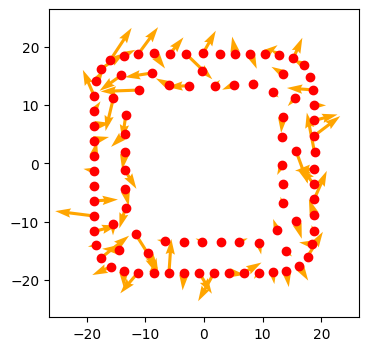

In [102]:
%matplotlib inline
plot_intial_state(X0,Y0,Vx0,Vy0,scale=0.002)

#### Plot trajectories

In [88]:
%matplotlib auto
%matplotlib auto

plt.figure(figsize=(5,5))
for i in range(Np):
    X = s[0][:,i]
    Y = s[1][:,i]
    plt.plot(X,Y,'-r',lw=1,alpha=0.5)
    plt.plot(X[-1],Y[-1],'or',ms=4)
#D=5
#plt.xlim(-D,D)
#plt.ylim(-D,D)

a=np.arctanh(0.9)/slope + 5*width
b=np.arctanh(-0.9)/slope + 3*width
plot_boxes([-a,a,-a,a],[-b,b,-b,b])
plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


#### Animate trajectories

In [123]:
%matplotlib auto
%matplotlib auto

a=np.arctanh(0.9)/slope + 5*width
b=np.arctanh(-0.9)/slope + 3*width
ani.animate_path(self1,s,save=False,verbose=True,j0=1,dj=5*4,interval=10, 
                 comet=True, ltraj=100, b_param=b, plot_params=['-r','or',1, 6, 0.5], 
                 length=8,box1=[-a,a,-a,a],box2=[-b,b,-b,b])
#plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


#### Plot speed of the ith particle

In [6]:
i=10
Vx = s[2][:,i]
Vy = s[3][:,i]
V = np.sqrt(Vx**2+Vy**2)
tt = np.arange(len(Vx))*h

%matplotlib auto
plt.figure(figsize=(7,5))
plt.plot(tt,V,'-b',lw=1.5)
plt.hlines(0,tt[0],tt[-1],'black','--',lw=1,alpha=0.5)
plt.xlabel(r'$\bar{t}$')
plt.ylabel(r'$\overline{v}$')
plt.show()

Using matplotlib backend: QtAgg


#### Plot forces over time of the ith particle

In [7]:
LF = sim.get_net_force(s)
LF.shape

(5001, 65, 6)

In [8]:
i=10
plt.figure(figsize=(5,5))
iter = np.arange(len(LF[:,0]))
labels= ['Fx_elec','Fy_elec','Fx_fric','Fy_fric','Fx_ext','Fy_ext']
colors= ['red','blue','green','black','orange','cyan']
for j in range(6):
    plt.plot(iter,LF[:,i,j],'-',color=colors[j],lw=1.2, label=labels[j])
plt.legend()
plt.show()

#### Plot "current" over time

In [125]:
t0=50
LX = s[0]
LY = s[1]
b = np.arctanh(-0.9)/slope + 3*width
J = np.zeros(N)
for j in range(N):
    J[j] = -np.sum(s[3][j,:][(LY[j,:]>=-b)*(LY[j,:]<=b)*(LY[j,:]<0)]) + np.sum(s[2][j,:][LY[j,:]<b])+ np.sum(s[3][j,:][(LY[j,:]>=-b)*(LY[j,:]<=b)*(LX[j,:]>0)]) - np.sum(s[2][j,:][LY[j,:]>-b])
iter = np.arange(N)

plt.figure(figsize=(5,5))
plt.plot(iter*h,J,'-r',lw=1.2,label='J')
y=-np.sin(np.pi*iter*h/t0)*E_fem
y=y/np.max(y)*np.max(J)
plt.plot(iter*h,y,'-b',lw=1.2,label='V')
plt.legend()
#plt.savefig('images/current-fig '+get_time()+'.png',dpi=300)
plt.show()

#### Plot trajectory of the ith particle

In [124]:
i0=10

plt.figure(figsize=(5,5))
for i in [i0]:
    X = s[0][:,i]
    Y = s[1][:,i]
    plt.plot(X,Y,'-r',lw=1,alpha=0.5)
    plt.plot(X[-1],Y[-1],'or',ms=4)

a=np.arctanh(0.9)/slope + 5*width
b=np.arctanh(-0.9)/slope + 3*width
plot_boxes([-a,a,-a,a],[-b,b,-b,b])
plt.show()

#### Plot / animate electric field over time

In [11]:
import matplotlib.animation as animation

In [ ]:
LX, LY, LVx, LVy = s[0], s[1], s[2], s[3]
k=50; j0=10
LEx = np.zeros((N,k,k))
LEy = np.zeros((N,k,k))

a=np.arctanh(0.9)/slope + 5*width
tt=np.linspace(-a,a,k)
Xt, Yt = np.meshgrid(tt,tt)

for i in range(N):
    Field1 = E2(Xt,Yt,h*i)
    LEx[i] = Field1[0]
    LEy[i] = Field1[1]
    for j in range(Np):
        if j==j0: continue
        dX = Xt-LX[i,j]
        dY = Yt-LY[i,j]
        R = np.sqrt(dX**2 + dY**2+1e-5)
        #cond = R>=5.0
        LEx[i] += -dX/R**3
        LEy[i] += -dY/R**3

In [22]:
%matplotlib auto
%matplotlib auto

j0=10

def update(j):
    ax.clear()
    U, V = -LEx[j], -LEy[j]
    Norm = np.sqrt(U**2+V**2)
    plt.quiver(Xt, Yt, U/Norm, V/Norm, scale_units='xy',angles='xy',scale=0.8,color='orange',width=0.002,label=r'$n=$'+f'{j}\n'+r'$\overline{t}=$ '+f'{np.round(j*h,1)}')
    plt.plot(LX[j],LY[j],'ob',ms=4)
    plt.plot(LX[j][j0], LY[j][j0],'or',ms=4, label='particle of interest')
    a=np.arctanh(0.9)/slope + 5*width
    b=np.arctanh(-0.9)/slope + 3*width
    plot_boxes([-a,a,-a,a],[-b,b,-b,b])
    plt.legend(loc='upper right')
dj=10

fig = plt.figure(figsize=(7,7))
ax = fig.gca()
anim = animation.FuncAnimation(fig,update,range(0,N,dj), repeat=False, interval=150)
#anim.save('field_.mp4',writer='ffmpeg')

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


##### Plot electric field of an interation

In [133]:
%matplotlib auto
%matplotlib auto
i=1000; j0=10; k=100

LX, LY = s[0], s[1]
LEx = np.zeros((k,k))
LEy = np.zeros((k,k))

a=np.arctanh(0.9)/slope + 5*width
tt=np.linspace(-a,a,k)
Xt, Yt = np.meshgrid(tt,tt)

Field1 = E2(Xt,Yt,h*i)
#LEx = Field1[0]
#LEy = Field1[1]
LEx += E_fem*(Yt<-ycut)

for j in range(Np):
    if j==j0: continue
    dX = Xt-LX[i,j]
    dY = Yt-LY[i,j]
    R = np.sqrt(dX**2 + dY**2+1e-5)
    ii=R>1
    LEx += -dX/R**3*ii
    LEy += -dY/R**3*ii

U, V = -LEx, -LEy
Norm = np.sqrt(U**2+V**2)
Norm = 1

fig = plt.figure(figsize=(9,9))
plt.quiver(Xt, Yt, U/Norm, V/Norm, scale_units='xy',angles='xy',scale=0.5,color='orange',
           width=0.001,label=r'$n=$'+f'{i}\n'+r'$\overline{t}=$ '+f'{np.round(i*h,1)}')
plt.plot(LX[i],LY[i],'ob',ms=4)
plt.plot(LX[i,j0], LY[i,j0],'or',ms=4, label='particle of interest')
a=np.arctanh(0.9)/slope + 5*width
b=np.arctanh(-0.9)/slope + 3*width
plot_boxes([-a,a,-a,a],[-b,b,-b,b])
plt.legend(loc='upper right')
plt.savefig('images/field-fig '+get_time()+'.png',dpi=300)
plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg
